In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

In [69]:
import random

np.random.seed(42)
random.seed(42)

In [70]:
df = pd.read_csv("../data/raw/train.csv")

df.head()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,...,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


In [71]:
print(df.shape)

(58592, 44)


In [72]:
df.columns

Index(['policy_id', 'policy_tenure', 'age_of_car', 'age_of_policyholder',
       'area_cluster', 'population_density', 'make', 'segment', 'model',
       'fuel_type', 'max_torque', 'max_power', 'engine_type', 'airbags',
       'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'gear_box', 'steering_type', 'turning_radius',
       'length', 'width', 'height', 'gross_weight', 'is_front_fog_lights',
       'is_rear_window_wiper', 'is_rear_window_washer',
       'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating', 'is_claim'],
      dtype='object')

In [73]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   policy_tenure                     58592 non-null  float64
 2   age_of_car                        58592 non-null  float64
 3   age_of_policyholder               58592 non-null  float64
 4   area_cluster                      58592 non-null  object 
 5   population_density                58592 non-null  int64  
 6   make                              58592 non-null  int64  
 7   segment                           58592 non-null  object 
 8   model                             58592 non-null  object 
 9   fuel_type                         58592 non-null  object 
 10  max_torque                        58592 non-null  object 
 11  max_power                         58592 non-null  object 
 12  engi

In [74]:
df.describe()

,policy_tenure,age_of_car,age_of_policyholder,population_density,make,airbags,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,ncap_rating,is_claim
count,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.00000,58592.000000,58592.000000,58592.000000
mean,0.611246,0.069424,0.469420,18826.858667,1.763722,3.137066,1162.355851,3.626963,5.245443,4.852893,3850.476891,1672.233667,1553.33537,1385.276813,1.759950,0.063968
std,0.414156,0.056721,0.122886,17660.174792,1.136988,1.832641,266.304786,0.483616,0.430353,0.228061,311.457119,112.089135,79.62227,212.423085,1.389576,0.244698
min,0.002735,0.000000,0.288462,290.000000,1.000000,1.000000,796.000000,3.000000,5.000000,4.500000,3445.000000,1475.000000,1475.00000,1051.000000,0.000000,0.000000
25%,0.210250,0.020000,0.365385,6112.000000,1.000000,2.000000,796.000000,3.000000,5.000000,4.600000,3445.000000,1515.000000,1475.00000,1185.000000,0.000000,0.000000
50%,0.573792,0.060000,0.451923,8794.000000,1.000000,2.000000,1197.000000,4.000000,5.000000,4.800000,3845.000000,1735.000000,1530.00000,1335.000000,2.000000,0.000000
75%,1.039104,0.110000,0.548077,27003.000000,3.000000,6.000000,1493.000000,4.000000,5.000000,5.000000,3995.000000,1755.000000,1635.00000,1510.000000,3.000000,0.000000
max,1.396641,1.000000,1.000000,73430.000000,5.000000,6.000000,1498.000000,4.000000,6.000000,5.200000,4300.000000,1811.000000,1825.00000,1720.000000,5.000000,1.000000


In [75]:
df['is_claim'].value_counts()

is_claim
0    54844
1     3748
Name: count, dtype: int64

In [76]:
X = df.drop("is_claim", axis=1)
y = df["is_claim"]

# Car Insurance Claim Prediction

This project aims to predict whether a customer will make an insurance claim using machine learning models.

The workflow includes:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Model building
- Hyperparameter tuning
- Model evaluation
- Business insights

## Data Loading

The dataset is loaded using pandas. It contains customer, vehicle, and policy-related features along with the target variable `is_claim`.

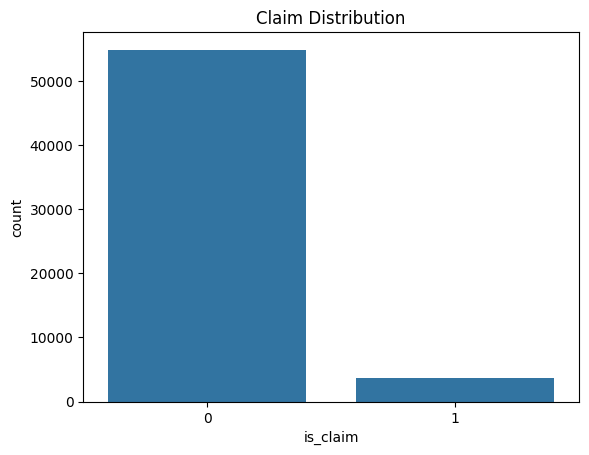

In [77]:
sns.countplot(x='is_claim', data=df)
plt.title("Claim Distribution")
plt.show()

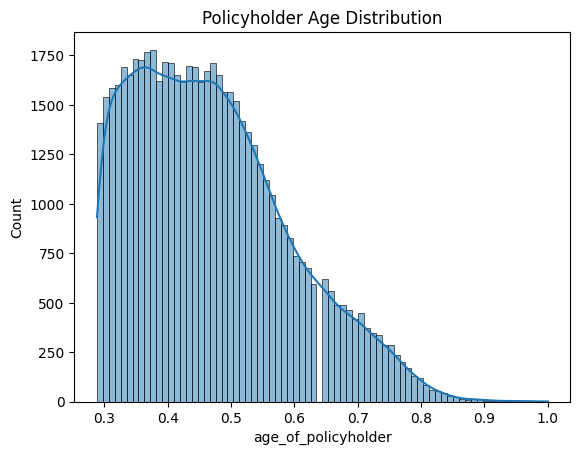

In [78]:
sns.histplot(df['age_of_policyholder'], kde=True)
plt.title("Policyholder Age Distribution")
plt.show()

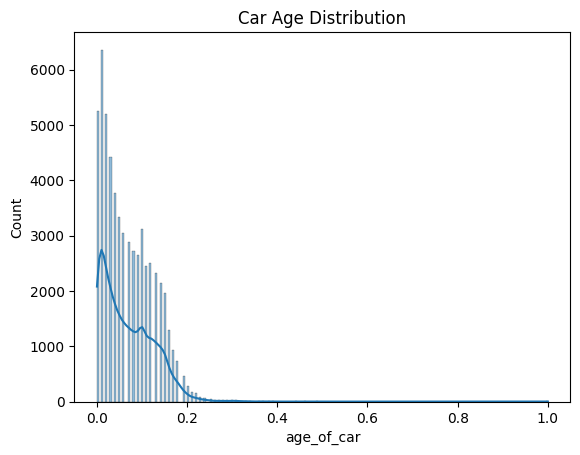

In [79]:
sns.histplot(df['age_of_car'], kde=True)
plt.title("Car Age Distribution")
plt.show()

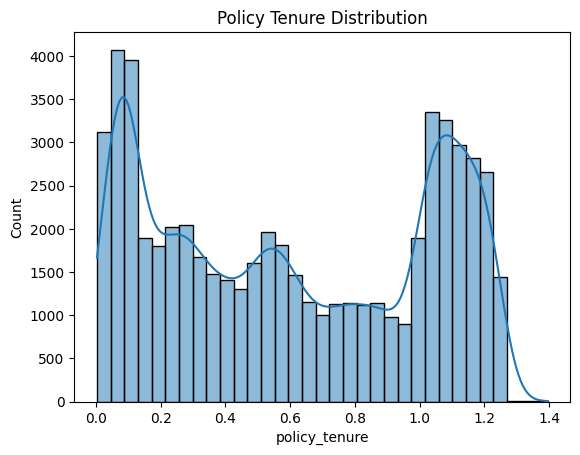

In [80]:
sns.histplot(df['policy_tenure'], kde=True)
plt.title("Policy Tenure Distribution")
plt.show()

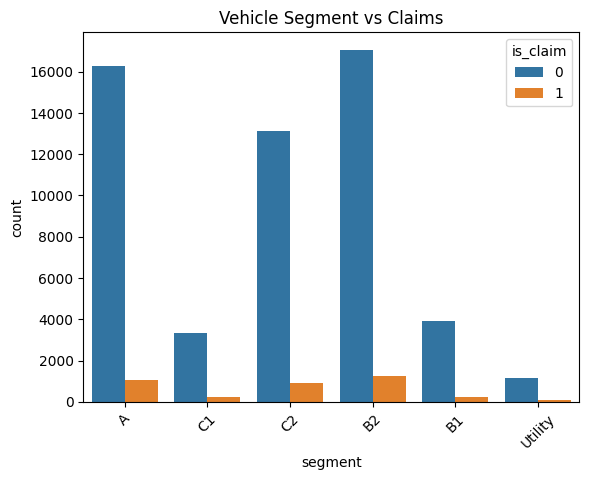

In [81]:
sns.countplot(x='segment', hue='is_claim', data=df)
plt.xticks(rotation=45)
plt.title("Vehicle Segment vs Claims")
plt.show()

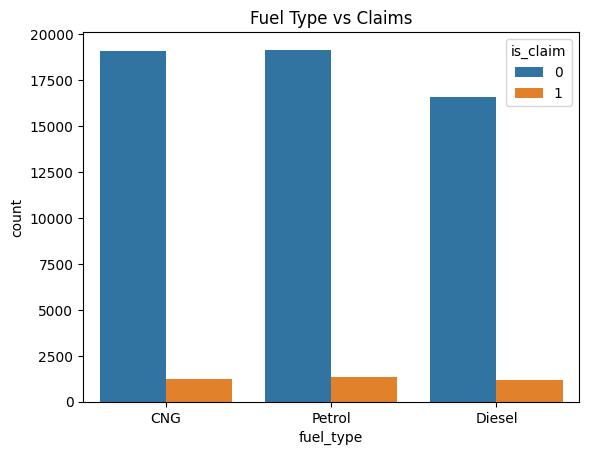

In [82]:
sns.countplot(x='fuel_type', hue='is_claim', data=df)
plt.title("Fuel Type vs Claims")
plt.show()

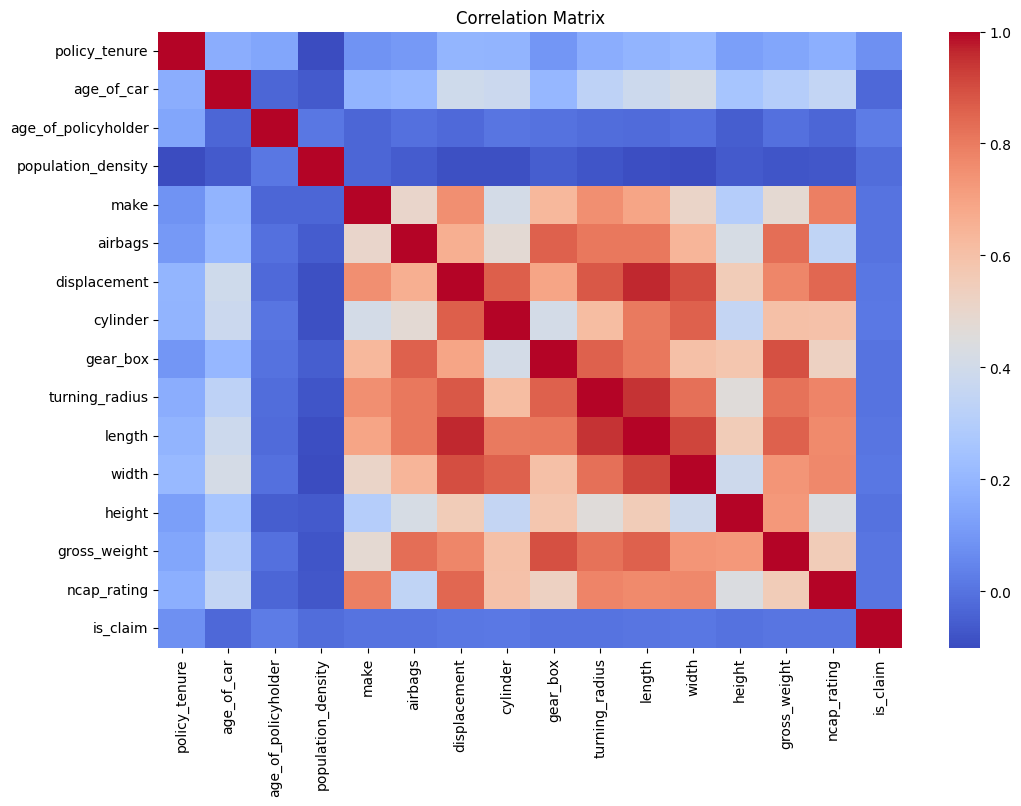

In [83]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [84]:
print(df.isnull().sum())

policy_id                           0
policy_tenure                       0
age_of_car                          0
age_of_policyholder                 0
area_cluster                        0
population_density                  0
make                                0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
gear_box                            0
steering_type                       0
turning_radius                      0
length      

## Exploratory Data Analysis (EDA)

In this step, we:
- Understand dataset structure
- Check missing values
- Analyze target distribution
- Identify feature types

EDA helps in understanding patterns and potential issues in the dataset.

## Train-Test Split

The dataset is split into:
- Training set (80%)
- Testing set (20%)

This ensures unbiased evaluation of the model on unseen data.

In [85]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

In [86]:
X_encoded = X.copy()

for col in X_encoded.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [88]:
X.dtypes

policy_id                            object
policy_tenure                       float64
age_of_car                          float64
age_of_policyholder                 float64
area_cluster                         object
population_density                    int64
make                                  int64
segment                              object
model                                object
fuel_type                            object
max_torque                           object
max_power                            object
engine_type                          object
airbags                               int64
is_esc                               object
is_adjustable_steering               object
is_tpms                              object
is_parking_sensors                   object
is_parking_camera                    object
rear_brakes_type                     object
displacement                          int64
cylinder                              int64
transmission_type               

In [89]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

## Feature and Target Split

The dataset is divided into:
- **Features (X)**: Input variables
- **Target (y)**: `is_claim` (0 or 1)

This separation is required for model training.

## Data Preprocessing

Categorical features are encoded using Label Encoding.

Why Label Encoding?
- Avoids high memory usage caused by OneHotEncoding
- Suitable for tree-based models like XGBoost

All features are converted to numeric format for model compatibility.

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [91]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [92]:
print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

Logistic Regression
Accuracy: 0.9354893762266405
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [93]:
print(classification_report(y_test, y_pred_log))

c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10963
           1       0.00      0.00      0.00       756

    accuracy                           0.94     11719
   macro avg       0.47      0.50      0.48     11719
weighted avg       0.88      0.94      0.90     11719



c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [94]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [95]:
print("Decision Tree")

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.8727707142247632
Precision: 0.0847457627118644
Recall: 0.0992063492063492
F1 Score: 0.09140767824497258


In [96]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.94      0.93      0.93     10963
           1       0.08      0.10      0.09       756

    accuracy                           0.87     11719
   macro avg       0.51      0.51      0.51     11719
weighted avg       0.88      0.87      0.88     11719



In [97]:
baseline_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt)
    ]
})

baseline_results

c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.935489,0.000000,0.000000,0.000000
1,Decision Tree,0.872771,0.084746,0.099206,0.091408


## Baseline Models

We train multiple baseline models:
- Logistic Regression
- Decision Tree
- Random Forest

These models provide a performance benchmark before using advanced models.

In [98]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [99]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [100]:
print("Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9348067241232187
Precision: 0.21428571428571427
Recall: 0.003968253968253968
F1 Score: 0.007792207792207792


In [101]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10963
           1       0.21      0.00      0.01       756

    accuracy                           0.93     11719
   macro avg       0.57      0.50      0.49     11719
weighted avg       0.89      0.93      0.90     11719



In [102]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [103]:
print("XGBoost")

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

XGBoost
Accuracy: 0.9354893762266405
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [104]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10963
           1       0.00      0.00      0.00       756

    accuracy                           0.94     11719
   macro avg       0.47      0.50      0.48     11719
weighted avg       0.88      0.94      0.90     11719


c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [105]:
lgb_model = LGBMClassifier(n_estimators=100)

lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)

[LightGBM] [Info] Number of positive: 2992, number of negative: 43881
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025742 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 842
[LightGBM] [Info] Number of data points in the train set: 46873, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.063832 -> initscore=-2.685539
[LightGBM] [Info] Start training from score -2.685539


In [106]:
print("LightGBM")

print("Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("Precision:", precision_score(y_test, y_pred_lgb))
print("Recall:", recall_score(y_test, y_pred_lgb))
print("F1 Score:", f1_score(y_test, y_pred_lgb))

LightGBM
Accuracy: 0.9354893762266405
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [107]:
print(classification_report(y_test, y_pred_lgb))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10963
           1       0.00      0.00      0.00       756

    accuracy                           0.94     11719
   macro avg       0.47      0.50      0.48     11719
weighted avg       0.88      0.94      0.90     11719



c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [108]:
advanced_results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgb)
    ]
})

advanced_results

,Model,Accuracy,F1 Score
0,Random Forest,0.934807,0.007792
1,XGBoost,0.935489,0.000000
2,LightGBM,0.935489,0.000000


In [109]:
from sklearn.metrics import f1_score

model_results = pd.DataFrame({
    "Model": ["Logistic", "Decision Tree", "Random Forest", "XGBoost", "LightGBM"],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgb)
    ]
})

model_results.sort_values(by="F1 Score", ascending=False)

,Model,F1 Score
1,Decision Tree,0.091408
2,Random Forest,0.007792
0,Logistic,0.000000
3,XGBoost,0.000000
4,LightGBM,0.000000


## XGBoost Model

XGBoost is a powerful gradient boosting algorithm that:
- Handles large datasets efficiently
- Provides high performance
- Works well with structured data

It is used as the primary model for this project.

## LightGBM Model

LightGBM is another gradient boosting framework that:
- Is faster than traditional boosting methods
- Handles large-scale data efficiently

Used for comparison with XGBoost.

In [110]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

best_score = -1
best_params = None
best_model = None

In [111]:
for n in [100, 150]:
    for depth in [3, 5]:
        for lr in [0.05, 0.1]:

            model = XGBClassifier(
                n_estimators=100,
                max_depth=5,
                learning_rate=0.1,
                subsample=0.8,
                n_jobs=-1,
                eval_metric='logloss'
            )

            model.fit(X_tr, y_tr)

            y_pred = model.predict(X_val)
            score = f1_score(y_val, y_pred)

            print(f"n={n}, depth={depth}, lr={lr} → F1={score:.4f}")

            if score > best_score:
                best_score = score
                best_params = {
                    "n_estimators": n,
                    "max_depth": depth,
                    "learning_rate": lr
                }
                best_model = model

print("\n Best F1 Score:", best_score)
print("Best Parameters:", best_params)

n=100, depth=3, lr=0.05 → F1=0.0000
n=100, depth=3, lr=0.1 → F1=0.0000
n=100, depth=5, lr=0.05 → F1=0.0000
n=100, depth=5, lr=0.1 → F1=0.0000
n=150, depth=3, lr=0.05 → F1=0.0000
n=150, depth=3, lr=0.1 → F1=0.0000
n=150, depth=5, lr=0.05 → F1=0.0000
n=150, depth=5, lr=0.1 → F1=0.0000

 Best F1 Score: 0.0
Best Parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}


In [112]:
y_pred_final = best_model.predict(X_test)

In [113]:
print("Final Tuned XGBoost Model")
print(classification_report(y_test, y_pred_final))

Final Tuned XGBoost Model
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10963
           1       0.00      0.00      0.00       756

    accuracy                           0.94     11719
   macro avg       0.47      0.50      0.48     11719
weighted avg       0.88      0.94      0.90     11719



c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ak\Documents\car-insurance-claim-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [114]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
2,age_of_car,0.050099
20,displacement,0.049850
21,cylinder,0.049052
8,model,0.048299
1,policy_tenure,0.043848
29,gross_weight,0.043685
15,is_adjustable_steering,0.041711
18,is_parking_camera,0.037802
9,fuel_type,0.037739
39,is_day_night_rear_view_mirror,0.037733


## Hyperparameter Tuning

Hyperparameter tuning was performed manually by testing different combinations of:
- n_estimators
- max_depth
- learning_rate

A validation set was used to evaluate performance using F1-score.

This approach was chosen because:
- It is faster than GridSearchCV
- Avoids memory issues
- Provides efficient parameter selection

## Model Evaluation

The model is evaluated using:
- Classification Report (Precision, Recall, F1-score)
- Accuracy
- ROC Curve

F1-score is used as the primary metric due to class imbalance.

## Feature Importance

Feature importance helps identify:
- Which variables impact predictions the most
- Key drivers of insurance claims

This is useful for business decision-making.

In [115]:
from sklearn.metrics import roc_curve, roc_auc_score

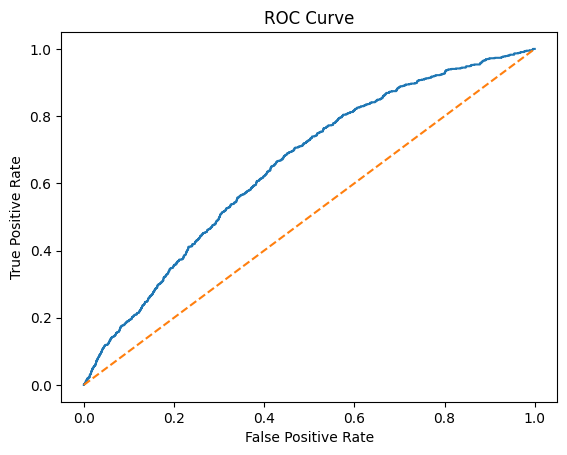

In [116]:
y_prob = xgb_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [117]:
auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])
print("AUC Score:", auc)

AUC Score: 0.6445542896331914


## ROC Curve

The ROC Curve visualizes the trade-off between:
- True Positive Rate (TPR)
- False Positive Rate (FPR)

A higher AUC score indicates better model performance.

## Business Insights

Key insights from the model:
- Certain features strongly influence claim probability
- High-risk customers can be identified in advance

Business impact:
- Better risk assessment
- Improved pricing strategies
- Enhanced fraud detection

In [118]:
import joblib

In [122]:
joblib.dump(xgb_model, "../models/xgb_model_v2.pkl")

['../models/xgb_model_v2.pkl']

In [123]:
joblib.dump(X_train.columns.tolist(), "../models/columns.pkl")

['../models/columns.pkl']

In [124]:
loaded_model = joblib.load("../models/xgb_model_v2.pkl")

predictions = loaded_model.predict(X_test)

print("Model loaded successfully")

Model loaded successfully


## Model Saving

The final trained model is saved using joblib.

This allows:
- Reuse of the model
- Deployment in applications (e.g., Streamlit)